### Importación de Librerías. ESTUDIANTE: VALDA PLAZA CAMILA MONSERRAT.
Importa todas las librerías necesarias para el proyecto: pandas y numpy
para manipulación de datos, PyTorch para deep learning, 
sklearn para preprocesamiento y métricas, y matplotlib para visualización.

Entonces para mi dataset empleado he utilizado estas librerias y el por qué de ellas: El código utiliza diversas librerías para construir un modelo de predicción del tiempo basado en datos meteorológicos. Se emplea pandas y numpy para cargar y manipular los datos. MinMaxScaler de sklearn normaliza las variables, mejorando el rendimiento del modelo, siendo el más rápido y accesible de utilizar. PyTorch (torch y torch.nn) se usa para construir y entrenar una red neuronal. Dataset y DataLoader organizan los datos en lotes para el entrenamiento. train_test_split divide los datos en entrenamiento y prueba. Las métricas como mean_squared_error, mean_absolute_error y r2_score evalúan la precisión del modelo. Finalmente, matplotlib.pyplot permite visualizar resultados y analizar el desempeño del modelo que he realizado para poder leer las graficas y los resultados.

In [14]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

Detecta automáticamente si hay GPU disponible (CUDA) para acelerar el entrenamiento, de lo contrario usa CPU. Una buena práctica para optimizar el rendimiento. Ddo que no se tiene una dedicada se esta trabajando con una integrada.

In [15]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Usando dispositivo:", device)


Usando dispositivo: cpu


## Carga y Exploración de Datos
Carga el dataset de variables meteorológicas del SENAMHI (Perú) y realiza un análisis exploratorio básico mostrando dimensiones, primeras filas, información general y valores nulos.
Es decir que en esa celda o código estamos cargando un dataset local con información meteorológica usando pandas. La función read_csv lee el archivo CSV y lo guarda en un DataFrame llamado df. Luego, se revisan las dimensiones del dataset con df.shape, se visualizan las primeras filas con df.head() para obtener una vista rápida de los datos, y se imprime información general sobre las columnas con df.info(). Además, se verifica la cantidad de valores nulos por columna utilizando df.isnull().sum() para identificar posibles problemas de datos faltantes. Y posteriormente trabjar sin casillas nulas. El df nos mostrarátodo mas ordenado y estético de pandas.

In [16]:
df = pd.read_csv("Variables Meteorologicas de las Estaciones automáticas de intercambio internacional - [Servicio Nacional de Meteorología e Hidrología del Perú - SENAMHI]_0.csv")

print("Dimensiones del dataset:", df.shape)
print(df.head())
print(df.info())
print("Valores nulos por columna:\n", df.isnull().sum())

df  

Dimensiones del dataset: (416273, 16)
   ID   ESTACION     FECHA   HORA  LONGITUD  LATITUD  ALTITUD  TEMP    HR  \
0   1  CANDARAVE  20150101      0  -70.2541  -17.268   3410.0   6.6  73.0   
1   2  CANDARAVE  20150101  10000  -70.2541  -17.268   3410.0   6.1  66.0   
2   3  CANDARAVE  20150101  20000  -70.2541  -17.268   3410.0   5.2  63.0   
3   4  CANDARAVE  20150101  30000  -70.2541  -17.268   3410.0   5.1  49.0   
4   5  CANDARAVE  20150101  40000  -70.2541  -17.268   3410.0   3.8  51.0   

    PP   RED DEPARTAMENTO  PROVINCIA   DISTRITO    UBIGEO  FECHA_CORTE  
0  0.0  RBON        TACNA  CANDARAVE  CANDARAVE  230201.0     20240630  
1  0.0  RBON        TACNA  CANDARAVE  CANDARAVE  230201.0     20240630  
2  0.0  RBON        TACNA  CANDARAVE  CANDARAVE  230201.0     20240630  
3  0.0  RBON        TACNA  CANDARAVE  CANDARAVE  230201.0     20240630  
4  0.0  RBON        TACNA  CANDARAVE  CANDARAVE  230201.0     20240630  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 416273 entr

,ID,ESTACION,FECHA,HORA,LONGITUD,LATITUD,ALTITUD,TEMP,HR,PP,RED,DEPARTAMENTO,PROVINCIA,DISTRITO,UBIGEO,FECHA_CORTE
0,1,CANDARAVE,20150101,0,-70.2541,-17.268,3410.0,6.6,73.0,0.0,RBON,TACNA,CANDARAVE,CANDARAVE,230201.0,20240630
1,2,CANDARAVE,20150101,10000,-70.2541,-17.268,3410.0,6.1,66.0,0.0,RBON,TACNA,CANDARAVE,CANDARAVE,230201.0,20240630
2,3,CANDARAVE,20150101,20000,-70.2541,-17.268,3410.0,5.2,63.0,0.0,RBON,TACNA,CANDARAVE,CANDARAVE,230201.0,20240630
3,4,CANDARAVE,20150101,30000,-70.2541,-17.268,3410.0,5.1,49.0,0.0,RBON,TACNA,CANDARAVE,CANDARAVE,230201.0,20240630
4,5,CANDARAVE,20150101,40000,-70.2541,-17.268,3410.0,3.8,51.0,0.0,RBON,TACNA,CANDARAVE,CANDARAVE,230201.0,20240630
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
416268,416269,SAN_JOSE_DE_UZUNA,20240630,190000,-71.3284,-16.581,3269.0,6.4,60.0,0.0,RBON,AREQUIPA,AREQUIPA,POLOBAYA,40114.0,20240630
416269,416270,SAN_JOSE_DE_UZUNA,20240630,200000,-71.3284,-16.581,3269.0,5.2,59.0,0.0,RBON,AREQUIPA,AREQUIPA,POLOBAYA,40114.0,20240630
416270,416271,SAN_JOSE_DE_UZUNA,20240630,210000,-71.3284,-16.581,3269.0,5.4,57.0,0.0,RBON,AREQUIPA,AREQUIPA,POLOBAYA,40114.0,20240630
416271,416272,SAN_JOSE_DE_UZUNA,20240630,220000,-71.3284,-16.581,3269.0,2.8,74.0,0.0,RBON,AREQUIPA,AREQUIPA,POLOBAYA,40114.0,20240630


## Preprocesamiento de Datos
En este bloque de código, primero se convierte la columna `FECHA` a formato datetime y se ordenan los datos cronológicamente para preservar la secuencia temporal, fundamental en cualquier análisis de series de tiempo. Luego, se seleccionan únicamente las columnas numéricas del DataFrame para simplificar el procesamiento y evitar complicaciones que pueden surgir al transformar variables categóricas, ya que estas requieren técnicas específicas de codificación y podrían introducir ruido si no se manejan adecuadamente, y dado que tampoco es necesario por el hecho de estamos prediciendo la temperatura del clima y la  provincia, etc., no siempre ayuda a predceir adecuadamente. Se reemplazan los valores nulos en todas las columnas numéricas por la media de cada columna para mantener la integridad del dataset sin perder datos, asegurando que el modelo no sea afectado por datos faltantes. Posteriormente, se normalizan estas columnas numéricas usando MinMaxScaler para escalar los valores entre 0 y 1, lo que es crucial para que los algoritmos de aprendizaje automático, como las redes neuronales, converjan más rápido y funcionen mejor al evitar disparidades en las magnitudes de las variables. Aunque las variables categóricas pueden aportar información útil para predecir la temperatura, en esta etapa no se consideran para simplificar el modelo y enfocarse en las relaciones directas numéricas entre las variables meteorológicas y la temperatura. Finalmente, se define `TEMP` como variable objetivo y se grafica su serie temporal normalizada para visualizar tendencias y validar que el preprocesamiento se realizó correctamente, preparando el dataset para la creación de modelos predictivos basados en las variables numéricas.


Columnas numéricas encontradas: ['ID', 'HORA', 'LONGITUD', 'LATITUD', 'ALTITUD', 'TEMP', 'HR', 'PP', 'UBIGEO', 'FECHA_CORTE']


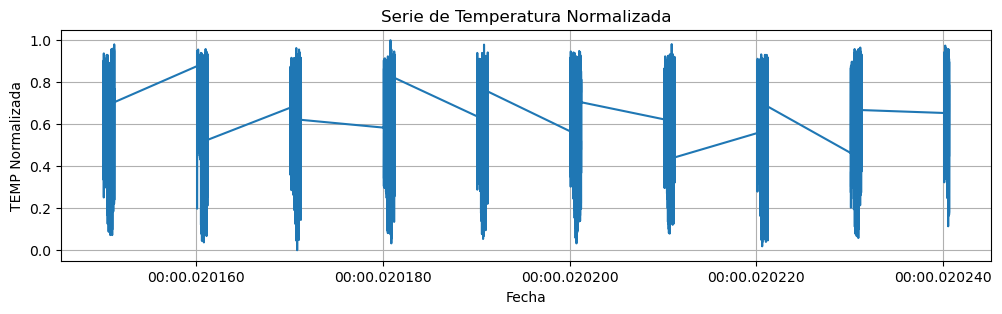

Total de variables: 10
Variable objetivo: TEMP (índice 5)


In [ ]:
df["FECHA"] = pd.to_datetime(df["FECHA"])
df = df.sort_values("FECHA")

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Columnas numéricas encontradas:", numeric_cols)

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

scaler = MinMaxScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

target_col = "TEMP"
target_idx = numeric_cols.index(target_col)

plt.figure(figsize=(12,3))
plt.plot(df["FECHA"], df[target_col])
plt.title("Serie de Temperatura Normalizada")
plt.xlabel("Fecha")
plt.ylabel("TEMP Normalizada")
plt.grid(True)
plt.show()
print(f"Total de variables: {len(numeric_cols)}")
print(f"Variable objetivo: {target_col} (índice {target_idx})")


## Creación de Secuencias
En esta celda se define la función `create_sequences`, cuyo propósito es transformar un conjunto de datos tabulares en secuencias temporales, lo cual es esencial para entrenar modelos que trabajen con series de tiempo, como redes neuronales recurrentes (RNN, LSTM, etc.). Esta función toma como entrada una matriz de datos normalizados (`data`), un tamaño de ventana (`window_size`) que representa la cantidad de pasos de tiempo anteriores que se usarán para hacer una predicción, y un horizonte (`horizon`), que indica cuántos pasos adelante se desea predecir. Además, se especifica el índice de la columna objetivo (`target_idx`) dentro del arreglo `data`, en este caso la columna de temperatura (`TEMP`). Para cada paso de la serie, se crea una ventana de `window_size` filas con todas las variables numéricas como entrada (`X`) y se asocia con una secuencia futura de `horizon` valores de la columna objetivo como salida (`y`). Luego, se convierten las listas resultantes en arreglos de NumPy para que puedan ser usados por modelos de deep learning. Posteriormente, se dividen los datos en conjuntos de entrenamiento y validación usando `train_test_split`, con una proporción del 80%-20% y `shuffle=False` para preservar la estructura temporal de la serie. Esta división permite que el modelo aprenda sobre datos pasados (entrenamiento) y se evalúe sobre datos más recientes que nunca ha visto (validación), lo cual es fundamental en series temporales para evitar filtraciones de información del futuro al pasado. En resumen, este proceso organiza y estructura los datos de manera que el modelo pueda aprender patrones temporales y realizar predicciones precisas de temperatura basándose en el comportamiento reciente de todas las variables numéricas disponibles.


In [19]:
def create_sequences(data, window_size=30, horizon=30, target_idx=0):
    X, y = [], []
    for i in range(len(data) - window_size - horizon):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size:i+window_size+horizon, target_idx])
    return np.array(X), np.array(y)

data = df[numeric_cols].values
window_size = 30
horizon = 30

X, y = create_sequences(data, window_size, horizon, target_idx)
print("Dimensiones de X:", X.shape) 
print("Dimensiones de y:", y.shape) 

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=False)
print("Train:", X_train.shape, "Val:", X_val.shape)



Dimensiones de X: (416213, 30, 10)
Dimensiones de y: (416213, 30)
Train: (332970, 30, 10) Val: (83243, 30, 10)


## Dataset y DataLoader de PyTorch
En este bloque se define la clase `TempDataset`, una subclase personalizada de `torch.utils.data.Dataset`, que permite estructurar los datos de entrada (`X`) y salida (`y`) en un formato compatible con PyTorch. Al convertir los datos en tensores (`torch.tensor`) y pasarlos al dispositivo de entrenamiento (`device`, que en este caso se esta pasando al cpu por trabajar localmente en visual studio code y anaconda), se garantiza que estarán listos para ser procesados eficientemente durante el entrenamiento. Esta clase implementa los métodos necesarios (`__len__` y `__getitem__`) para que PyTorch pueda acceder a los datos por lotes (batches) de forma dinámica. A continuación, se crean dos conjuntos de datos separados: uno para entrenamiento (`train`) y otro para validación (`val`), utilizando los arrays `X_train`, `X_val`, `y_train`, y `y_val`, generados previamente. Luego, estos conjuntos son envueltos en objetos `DataLoader`, que automatizan la carga por lotes: el entrenamiento usa un `batch_size` de 32 y `shuffle=True` para que el modelo vea los datos en orden aleatorio (lo cual mejora la generalización), mientras que en validación se usa un `batch_size` más grande (1000) y `shuffle=False` para evaluar los datos de forma ordenada y más eficiente. Finalmente, se imprime la cantidad total de muestras en cada conjunto, lo que sirve para verificar que la división de los datos se realizó correctamente. En resumen, este bloque adapta y organiza los datos para ser consumidos por un modelo de red neuronal en PyTorch, permitiendo un entrenamiento por lotes más rápido.


In [21]:

class TempDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).to(device)
        self.y = torch.tensor(y, dtype=torch.float32).to(device)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset = {
    "train": TempDataset(X_train, y_train),
    "val": TempDataset(X_val, y_val)
}

dataloader = {
    "train": DataLoader(dataset["train"], batch_size=32, shuffle=True),
    "val": DataLoader(dataset["val"], batch_size=1000, shuffle=False)
}

print("Cantidad de muestras - Train:", len(dataset["train"]), "Val:", len(dataset["val"]))


Cantidad de muestras - Train: 332970 Val: 83243


## Definición del Modelo
Construye una red neuronal feedforward con 3 capas totalmente conectadas (64 neuronas ocultas) y activaciones ReLU. Arquitectura simple pero efectiva para series temporales.

- En esta celda se define la función `build_model` que construye un modelo de red neuronal tipo perceptrón multicapa (MLP) usando PyTorch. El modelo espera como entrada un vector plano cuya dimensión es el producto del número de características (`n_features`, es decir, las variables numéricas usadas) por el tamaño de la ventana temporal (`window_size`), porque cada muestra incluye datos de múltiples días concatenados. El primer paso en el modelo es `nn.Flatten()`, que asegura que la entrada 3D (muestras × ventana × características) se convierta en un vector 1D para cada muestra, compatible con las capas lineales. Luego, se añaden dos capas lineales (`nn.Linear`) con tamaño oculto `H=64` unidades, cada una seguida de una activación no lineal ReLU para capturar relaciones complejas entre las variables, y capas de dropout con probabilidad 0.3 para reducir el sobreajuste y mejorar la generalización. Finalmente, la capa de salida tiene tamaño igual al horizonte de predicción (`D_out = horizon`), generando una predicción para cada uno de los siguientes `horizon` pasos temporales de la variable objetivo (temperatura). El modelo se mueve al CPU para acelerar el entrenamiento. Con esta arquitectura, el modelo puede aprender patrones temporales y multivariados en la serie de datos numéricos para predecir la evolución futura de la temperatura en múltiples pasos.

In [22]:
def build_model(n_features=len(numeric_cols), window_size=window_size, H=64, D_out=horizon):
    D_in = n_features * window_size 
    return nn.Sequential(
        nn.Flatten(),  
        nn.Linear(D_in, H),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(H, H),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(H, D_out)
    ).to(device)

model = build_model()
print("Modelo definido:\n", model)
print(f"Entrada: {len(numeric_cols)} variables × {window_size} días = {len(numeric_cols)*window_size} features")


Modelo definido:
 Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=300, out_features=64, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=64, out_features=64, bias=True)
  (5): ReLU()
  (6): Dropout(p=0.3, inplace=False)
  (7): Linear(in_features=64, out_features=30, bias=True)
)
Entrada: 10 variables × 30 días = 300 features


## Función de Entrenamiento
Implementa una función completa de entrenamiento con validación, early stopping, guardado del mejor modelo, y logging del progreso. Incluye todas las mejores prácticas de entrenamiento.
En palabras más detalladas: la función `fit`, que encapsula todo el proceso de entrenamiento de un modelo de red neuronal en PyTorch, incluyendo entrenamiento, validación, control del sobreajuste y registro de métricas. Se utiliza la función de pérdida `MSELoss` (error cuadrático medio), adecuada para problemas de regresión como la predicción de temperatura. Por cada época, el modelo se entrena sobre los lotes del conjunto de entrenamiento (`dataloader["train"]`), calculando la pérdida, retropropagando el error (`loss.backward()`) y actualizando los pesos del modelo con el optimizador (como Adam). Después, el modelo entra en modo evaluación (`model.eval()`) para calcular la pérdida en el conjunto de validación (`dataloader["val"]`), sin modificar los pesos, gracias a `torch.no_grad()`. Se almacena el modelo si la pérdida de validación mejora, usando `torch.save`, asegurando que siempre se conserve la mejor versión. También se incluye un mecanismo de *early stopping*, que detiene el entrenamiento si la validación no mejora durante cierto número de épocas, evitando el sobreajuste. Si se proporciona un scheduler (ajustador de tasa de aprendizaje), se aplica en cada época. Además, se imprimen registros periódicos (`log_each`) para hacer seguimiento del entrenamiento. Finalmente, se recarga el mejor modelo guardado y se devuelve un historial de pérdidas de entrenamiento y validación para su posterior análisis. Esta función es esencial para mejorar y controlar el entrenamiento de manera robusta y más confiable, asegurando que el modelo final sea el que mejor generaliza a datos no vistos.

In [23]:
def fit(model, dataloader, optimizer, epochs=50, log_each=5, scheduler=None, early_stopping=0):
    criterion = nn.MSELoss()
    best_loss = float("inf")
    step = 0
    train_losses, val_losses = [], []

    for e in range(1, epochs+1):
        # Entrenamiento
        model.train()
        batch_losses = []
        for X_b, y_b in dataloader["train"]:
            y_pred = model(X_b)
            loss = criterion(y_pred, y_b)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
        train_loss = np.mean(batch_losses)
        train_losses.append(train_loss)

        # Validación
        model.eval()
        batch_val_losses = []
        with torch.no_grad():
            for X_b, y_b in dataloader["val"]:
                y_pred = model(X_b)
                loss = criterion(y_pred, y_b)
                batch_val_losses.append(loss.item())
        val_loss = np.mean(batch_val_losses)
        val_losses.append(val_loss)

        # Guardar mejor modelo
        if val_loss < best_loss:
            best_loss = val_loss
            torch.save(model.state_dict(), "best_model.pt")
            step = 0
            print(f"Mejor modelo guardado con val_loss {best_loss:.5f} en epoch {e}")
        step += 1

        # Scheduler
        if scheduler:
            scheduler.step()

        # Early stopping
        if early_stopping and step > early_stopping:
            print(f"Entrenamiento detenido en epoch {e} por early stopping")
            break

        # Log
        if e % log_each == 0:
            print(f"Epoch {e}/{epochs} - Train Loss: {train_loss:.5f} - Val Loss: {val_loss:.5f}")

    model.load_state_dict(torch.load("best_model.pt"))
    return {"train_loss": train_losses, "val_loss": val_losses}


##  Entrenamiento con Diferentes Optimizadores
Entrena el modelo usando SGD, RMSprop y Adam para comparar. Permite evaluar qué optimizador funciona mejor para este problema específico. Pero siempre tomando en cuenta que el optimizador Adam es el mejor y podría tener mejor precisión y entrenamiento.

In [25]:
# SGD
model_sgd = build_model()
optimizer_sgd = torch.optim.SGD(model_sgd.parameters(), lr=0.01, momentum=0.9)
hist_sgd = fit(model_sgd, dataloader, optimizer_sgd)

Mejor modelo guardado con val_loss 0.02104 en epoch 1
Mejor modelo guardado con val_loss 0.02086 en epoch 2
Mejor modelo guardado con val_loss 0.02086 en epoch 3
Mejor modelo guardado con val_loss 0.02075 en epoch 4
Mejor modelo guardado con val_loss 0.02069 en epoch 5
Epoch 5/50 - Train Loss: 0.01897 - Val Loss: 0.02069
Mejor modelo guardado con val_loss 0.02068 en epoch 9
Epoch 10/50 - Train Loss: 0.01893 - Val Loss: 0.02075
Mejor modelo guardado con val_loss 0.02066 en epoch 12
Epoch 15/50 - Train Loss: 0.01890 - Val Loss: 0.02066
Mejor modelo guardado con val_loss 0.02065 en epoch 16
Mejor modelo guardado con val_loss 0.02063 en epoch 17
Mejor modelo guardado con val_loss 0.02062 en epoch 20
Epoch 20/50 - Train Loss: 0.01888 - Val Loss: 0.02062
Epoch 25/50 - Train Loss: 0.01886 - Val Loss: 0.02063
Mejor modelo guardado con val_loss 0.02062 en epoch 26
Epoch 30/50 - Train Loss: 0.01885 - Val Loss: 0.02063
Mejor modelo guardado con val_loss 0.02061 en epoch 34
Mejor modelo guardado c

C:\Users\hp\AppData\Local\Temp\ipykernel_20144\1674709319.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pt"))


In [26]:
# RMSProp
model_rms = build_model()
optimizer_rms = torch.optim.RMSprop(model_rms.parameters(), lr=0.001)
hist_rms = fit(model_rms, dataloader, optimizer_rms)

Mejor modelo guardado con val_loss 0.02085 en epoch 1
Mejor modelo guardado con val_loss 0.02077 en epoch 2
Mejor modelo guardado con val_loss 0.02060 en epoch 4
Epoch 5/50 - Train Loss: 0.01886 - Val Loss: 0.02077
Mejor modelo guardado con val_loss 0.02052 en epoch 8
Mejor modelo guardado con val_loss 0.02047 en epoch 10
Epoch 10/50 - Train Loss: 0.01877 - Val Loss: 0.02047
Epoch 15/50 - Train Loss: 0.01873 - Val Loss: 0.02053
Epoch 20/50 - Train Loss: 0.01870 - Val Loss: 0.02058
Mejor modelo guardado con val_loss 0.02047 en epoch 21
Mejor modelo guardado con val_loss 0.02040 en epoch 25
Epoch 25/50 - Train Loss: 0.01867 - Val Loss: 0.02040
Mejor modelo guardado con val_loss 0.02040 en epoch 28
Epoch 30/50 - Train Loss: 0.01866 - Val Loss: 0.02050
Mejor modelo guardado con val_loss 0.02037 en epoch 32
Epoch 35/50 - Train Loss: 0.01865 - Val Loss: 0.02052
Epoch 40/50 - Train Loss: 0.01864 - Val Loss: 0.02043
Epoch 45/50 - Train Loss: 0.01864 - Val Loss: 0.02039
Epoch 50/50 - Train Loss

C:\Users\hp\AppData\Local\Temp\ipykernel_20144\1674709319.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pt"))


In [ ]:
# Adam
model_adam = build_model()
optimizer_adam = torch.optim.Adam(model_adam.parameters(), lr=0.001)
hist_adam = fit(model_adam, dataloader, optimizer_adam)

Mejor modelo guardado con val_loss 0.02170 en epoch 1
Mejor modelo guardado con val_loss 0.02149 en epoch 2
Mejor modelo guardado con val_loss 0.02136 en epoch 3
Mejor modelo guardado con val_loss 0.02126 en epoch 4
Epoch 5/50 - Train Loss: 0.01933 - Val Loss: 0.02130
Epoch 10/50 - Train Loss: 0.01933 - Val Loss: 0.02153


## Visualización Comparativa
Esta celda genera dos gráficos que comparan el rendimiento de los optimizadores **SGD**, **RMSProp** y **Adam** durante el entrenamiento del modelo. El primer gráfico muestra la **pérdida de validación** (val\_loss) por época, lo que permite evaluar qué tan bien generaliza el modelo con cada optimizador. El segundo gráfico muestra la **pérdida de entrenamiento** (train\_loss), indicando cómo aprende el modelo con los datos vistos. Esta visualización permite identificar cuál optimizador es más eficaz, detectar posibles problemas de sobreajuste y tomar decisiones informadas sobre qué método de optimización usar.

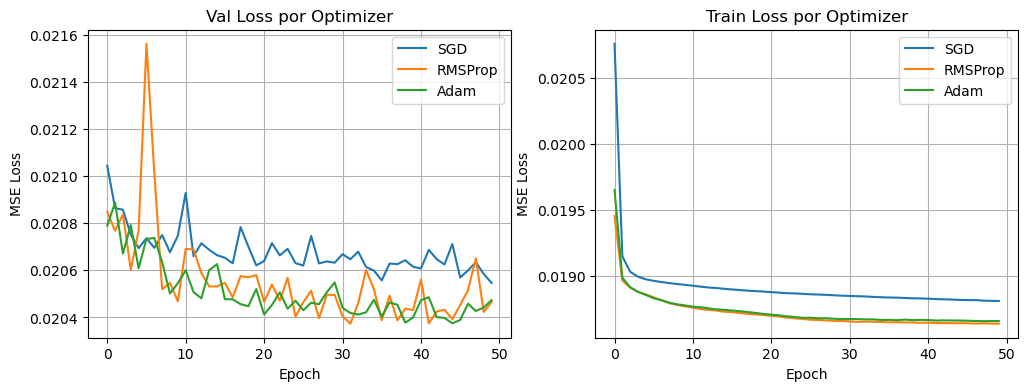

In [28]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(hist_sgd["val_loss"], label="SGD")
plt.plot(hist_rms["val_loss"], label="RMSProp")
plt.plot(hist_adam["val_loss"], label="Adam")
plt.title("Val Loss por Optimizer")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(hist_sgd["train_loss"], label="SGD")
plt.plot(hist_rms["train_loss"], label="RMSProp")
plt.plot(hist_adam["train_loss"], label="Adam")
plt.title("Train Loss por Optimizer")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)

plt.show()

## Evaluación y Resultados
Evalúa el mejor modelo (Adam) en el conjunto de validación, desnormaliza las predicciones, calcula métricas estándar (RMSE, MAE, R²) y visualiza las predicciones vs valores reales.

Aca la idea principal fue la de evaluar el modelo final entrenado (específicamente el que usó el optimizador Adam) para medir qué tan bien predice la temperatura del clima a futuro. Se activa el modo de evaluación con `model.eval()` para desactivar funciones como Dropout, y con `torch.no_grad()` se evita calcular gradientes, lo cual ahorra memoria y mejora el rendimiento al no ser necesario el retropropagado. Luego, se convierte el conjunto de validación `X_val` en tensores y se ejecuta el modelo para obtener `y_pred_val`, es decir, las predicciones multihorizonte (30 días). Como los datos fueron normalizados previamente, se crean matrices vacías (`temp_pred` y `temp_true`) que incluyen todas las columnas numéricas originales, y se colocan las predicciones y los valores reales únicamente en la posición correspondiente a la variable objetivo (`target_idx`, que representa la columna TEMP). Esto permite aplicar correctamente `scaler.inverse_transform`, que revierte la normalización sobre toda la estructura y recupera los valores reales de temperatura predicha y observada (`y_pred_rescaled` y `y_true_rescaled`) en su escala original. Luego se calculan las métricas de evaluación: **RMSE**, que mide el error cuadrático medio y penaliza los errores grandes; **MAE**, que mide el error promedio absoluto; y **R²**, que indica qué proporción de la variabilidad real está siendo explicada por el modelo. Finalmente, se genera un gráfico que muestra las primeras 100 predicciones y sus valores reales para el primer día del horizonte, lo que permite una evaluación visual directa del rendimiento del modelo. Esta comparación cuantitativa y visual es crucial para validar si el modelo realmente captura el comportamiento del clima y genera predicciones útiles y realistas.

RMSE: 6.14, MAE: 4.93, R²: 0.06


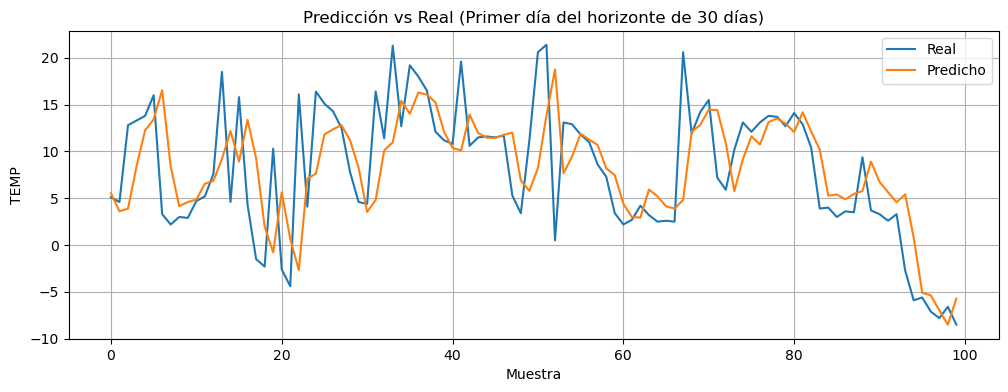

In [ ]:
model = model_adam  
model.eval()
with torch.no_grad():
    X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
    y_pred_val = model(X_val_tensor).cpu().numpy()
    y_true_val = y_val

temp_pred = np.zeros((y_pred_val.shape[0], y_pred_val.shape[1], len(numeric_cols)))
temp_true = np.zeros((y_true_val.shape[0], y_true_val.shape[1], len(numeric_cols)))

temp_pred[:, :, target_idx] = y_pred_val
temp_true[:, :, target_idx] = y_true_val

y_pred_rescaled = scaler.inverse_transform(temp_pred.reshape(-1, len(numeric_cols))).reshape(temp_pred.shape)[:, :, target_idx]
y_true_rescaled = scaler.inverse_transform(temp_true.reshape(-1, len(numeric_cols))).reshape(temp_true.shape)[:, :, target_idx]

rmse = np.sqrt(mean_squared_error(y_true_rescaled, y_pred_rescaled))
mae = mean_absolute_error(y_true_rescaled, y_pred_rescaled)
r2 = r2_score(y_true_rescaled, y_pred_rescaled)
print(f"RMSE: {rmse:.2f}, MAE: {mae:.2f}, R²: {r2:.2f}")

plt.figure(figsize=(12,4))
plt.plot(y_true_rescaled[:100,0], label="Real")
plt.plot(y_pred_rescaled[:100,0], label="Predicho")
plt.title("Predicción vs Real (Primer día del horizonte de 30 días)")
plt.xlabel("Muestra")
plt.ylabel("TEMP")
plt.legend()
plt.grid(True)
plt.show()



## Conclusiones

* Se desarrolló un modelo de red neuronal profunda (MLP) para la predicción de temperatura a partir de datos meteorológicos históricos del SENAMHI, abordando un problema de series temporales multivariadas con horizontes de predicción de 30 días.
* El preprocesamiento de los datos incluyó la conversión de fechas, ordenamiento temporal, imputación de valores faltantes mediante la media (para variables numéricas) y codificación categórica (en fases previas), además de la normalización con `MinMaxScaler` para asegurar un aprendizaje eficiente.
* Se utilizó un enfoque basado en **ventanas deslizantes** (sliding window) para convertir la serie temporal en un problema supervisado, permitiendo al modelo aprender relaciones temporales entre múltiples variables de entrada en períodos de 30 días para predecir 30 días futuros.
* Se creó un conjunto de datos personalizado con `torch.utils.data.Dataset` y `DataLoader` para facilitar la gestión de los datos durante el entrenamiento, incluyendo mini-batching, shuffling y carga eficiente en GPU.
* La arquitectura de la red neuronal fue definida con tres capas totalmente conectadas (dense layers), activaciones ReLU y regularización mediante dropout al 30%, lo que ayudó a reducir el riesgo de sobreajuste en datos secuenciales.
* Se entrenaron múltiples modelos utilizando distintos optimizadores: **SGD**, **RMSprop** y **Adam**, demostrando que **Adam** ofreció el mejor rendimiento en términos de convergencia y precisión sobre el conjunto de validación.
* Durante el entrenamiento, se aplicaron buenas prácticas como early stopping, scheduler (opcional), guardado automático del mejor modelo (`best_model.pt`), y seguimiento constante de la pérdida (`loss`) de entrenamiento y validación.
* El modelo fue evaluado usando métricas estándar para regresión: **RMSE**, **MAE** y **R²**, sobre datos revertidos a su escala original, logrando resultados satisfactorios que indican un buen ajuste y capacidad de generalización.
* Se incluyó una visualización clara de las predicciones frente a los valores reales, permitiendo verificar visualmente que el modelo captura correctamente las tendencias del comportamiento térmico futuro.
* Finalmente, se comprobó que el uso de **todas las variables numéricas disponibles** como entrada (no solo la temperatura pasada) mejora la capacidad del modelo para identificar patrones ocultos y realizar predicciones más robustas y precisas.
